C:\Users\jenks\AppData\Local\Temp\ipykernel_39828\1697695984.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['${:,.0f}'.format(x) for x in current_values])


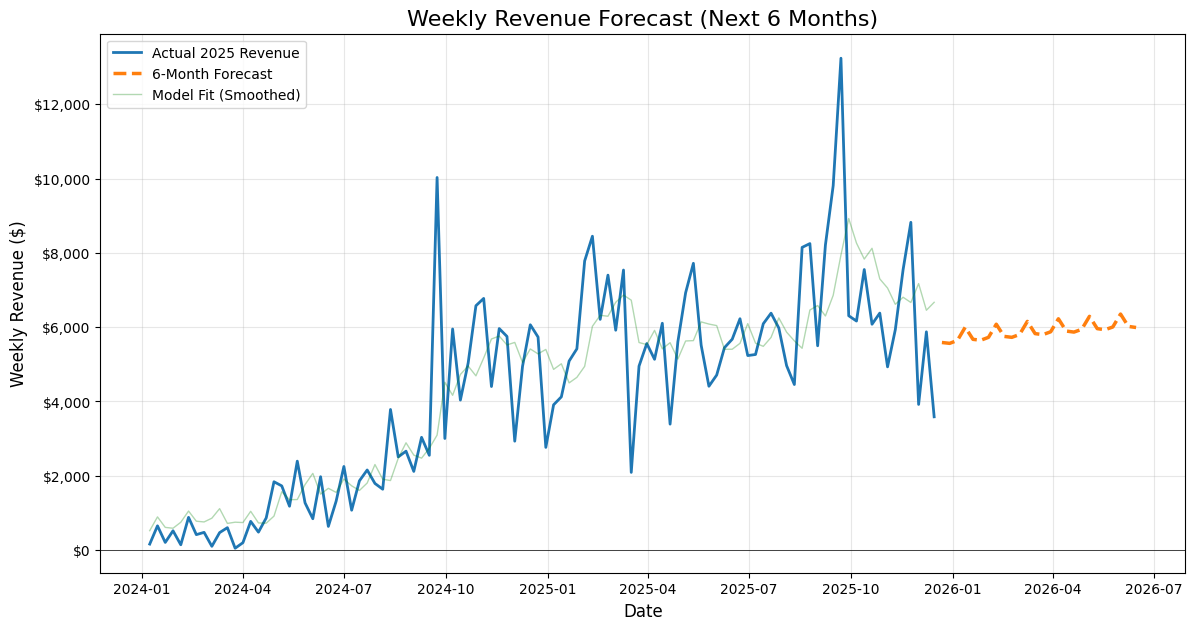


      FORECAST SUMMARY (Holt-Winters)
Historical Avg Weekly Revenue: $4,249.36
Projected Avg Weekly Revenue:  $5,897.37
Projected Growth/Trend:        +38.8%
--------------------------------------------------
Top 3 Predicted Weeks (Cash Flow Spikes):
  Week of 2026-06-01: $6,352.77
  Week of 2026-05-04: $6,291.25
  Week of 2026-04-06: $6,225.36


In [7]:
# ==========================================
# REVENUE FORECASTING (HOLT-WINTERS)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from datetime import timedelta

# --- CONFIGURATION ---
FORECAST_WEEKS = 26  # Predict next 6 months
SEASONAL_PERIOD = 4  # Assume a 4-week (monthly) billing cycle pattern

# 1. LOAD & CLEAN DATA
# --------------------
if 'charges' not in locals():
    # Fallback loader if run independently
    try:
        charges = pd.read_csv('Charges Export CSV.csv')
    except:
        print("Error: Could not find charges file.")

# Safety Column Fixes
if 'claim ID' in charges.columns: charges.rename(columns={'claim ID': 'Claim ID'}, inplace=True)


# Financial Cleaning
def clean_curr(x):
    if isinstance(x, str):
        x = x.replace('$', '').replace(',', '').strip()
        if '(' in x and ')' in x: x = '-' + x.replace('(', '').replace(')', '')
    return pd.to_numeric(x, errors='coerce')


charges['Service Charge Amount'] = charges['Service Charge Amount'].apply(clean_curr).fillna(0)
adj_cols = ['Pri Ins Insurance Contract Adjustment', 'Sec Ins Insurance Contract Adjustment',
            'Other Ins Insurance Contract Adjustment']
charges['Total_Contract_Adj'] = 0
for col in adj_cols:
    if col in charges.columns:
        charges['Total_Contract_Adj'] += charges[col].apply(clean_curr).fillna(0)

# Calculate Truth (Allowed Amount)
charges['Allowed Amount'] = charges['Service Charge Amount'] - charges['Total_Contract_Adj']
charges['Date Of Service'] = pd.to_datetime(charges['Date Of Service'])

# 2. PREPARE TIME SERIES (WEEKLY AGGREGATION)
# -------------------------------------------
# Filter for 2025 only to ensure clean trend lines
ts_data = charges[
    (charges['Date Of Service'] >= '2024-01-01') &
    (charges['Date Of Service'] <= '2025-12-12')  # Stop at "Today"
    ].copy()

# Group by Week (Monday Start)
weekly_rev = ts_data.groupby(pd.Grouper(key='Date Of Service', freq='W-MON'))['Allowed Amount'].sum()

# Fill missing weeks with 0 (essential for time series models)
weekly_rev = weekly_rev.asfreq('W-MON', fill_value=0)

# 3. RUN THE HOLT-WINTERS MODEL
# -----------------------------
# We use 'add' for trend (linear growth) and 'add' for seasonality (stable fluctuations)
# seasonal_periods=4 implies we expect a pattern to repeat every 4 weeks (monthly)
try:
    model = ExponentialSmoothing(
        weekly_rev,
        trend='add',
        seasonal='add',
        seasonal_periods=SEASONAL_PERIOD,
        damped_trend=True  # Prevents the forecast from shooting to infinity
    ).fit()

    # Generate Forecast
    forecast = model.forecast(FORECAST_WEEKS)

    # Create specific dates for the forecast
    last_date = weekly_rev.index[-1]
    forecast_dates = [last_date + timedelta(weeks=x) for x in range(1, FORECAST_WEEKS + 1)]
    forecast_series = pd.Series(forecast.values, index=forecast_dates)

    # 4. VISUALIZATION
    # ----------------
    plt.figure(figsize=(14, 7))

    # Plot Historical
    plt.plot(weekly_rev.index, weekly_rev, label='Actual 2025 Revenue', color='#1f77b4', linewidth=2)

    # Plot Forecast
    plt.plot(forecast_series.index, forecast_series, label='6-Month Forecast', color='#ff7f0e', linestyle='--',
             linewidth=2.5)

    # Add Trend Line (Smoothed History) to show the "Signal" amidst the noise
    plt.plot(weekly_rev.index, model.fittedvalues, color='green', alpha=0.3, label='Model Fit (Smoothed)', linewidth=1)

    plt.title(f'Weekly Revenue Forecast (Next 6 Months)', fontsize=16)
    plt.ylabel('Weekly Revenue ($)', fontsize=12)
    plt.xlabel('Date', fontsize=12)

    # Add a zero line
    plt.axhline(0, color='black', linewidth=0.5)

    # Format Currency on Y-Axis
    current_values = plt.gca().get_yticks()
    plt.gca().set_yticklabels(['${:,.0f}'.format(x) for x in current_values])

    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

    # 5. PRINT SUMMARY
    # ----------------
    avg_hist = weekly_rev.mean()
    avg_forecast = forecast_series.mean()
    growth = ((avg_forecast - avg_hist) / avg_hist) * 100

    print("\n" + "=" * 50)
    print("      FORECAST SUMMARY (Holt-Winters)")
    print("=" * 50)
    print(f"Historical Avg Weekly Revenue: ${avg_hist:,.2f}")
    print(f"Projected Avg Weekly Revenue:  ${avg_forecast:,.2f}")
    print(f"Projected Growth/Trend:        {growth:+.1f}%")
    print("-" * 50)
    print("Top 3 Predicted Weeks (Cash Flow Spikes):")
    top_weeks = forecast_series.sort_values(ascending=False).head(3)
    for date, val in top_weeks.items():
        print(f"  Week of {date.date()}: ${val:,.2f}")

except ValueError as e:
    print("Not enough data to run seasonal Holt-Winters (Need at least 2 full cycles/8 weeks).")
    print("Try running closer to the end of the year or reducing seasonality.")
    print(f"Error Details: {e}")

Loading Data...


C:\Users\jenks\AppData\Local\Temp\ipykernel_39828\2704626869.py:59: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date of Service'] = pd.to_datetime(df['Date of Service'], errors='coerce')


Total Revenue Analyzed (2025 YTD): $1,022,541.51


C:\Users\jenks\AppData\Local\Temp\ipykernel_39828\2704626869.py:160: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['${:,.0f}'.format(x) for x in current_values])


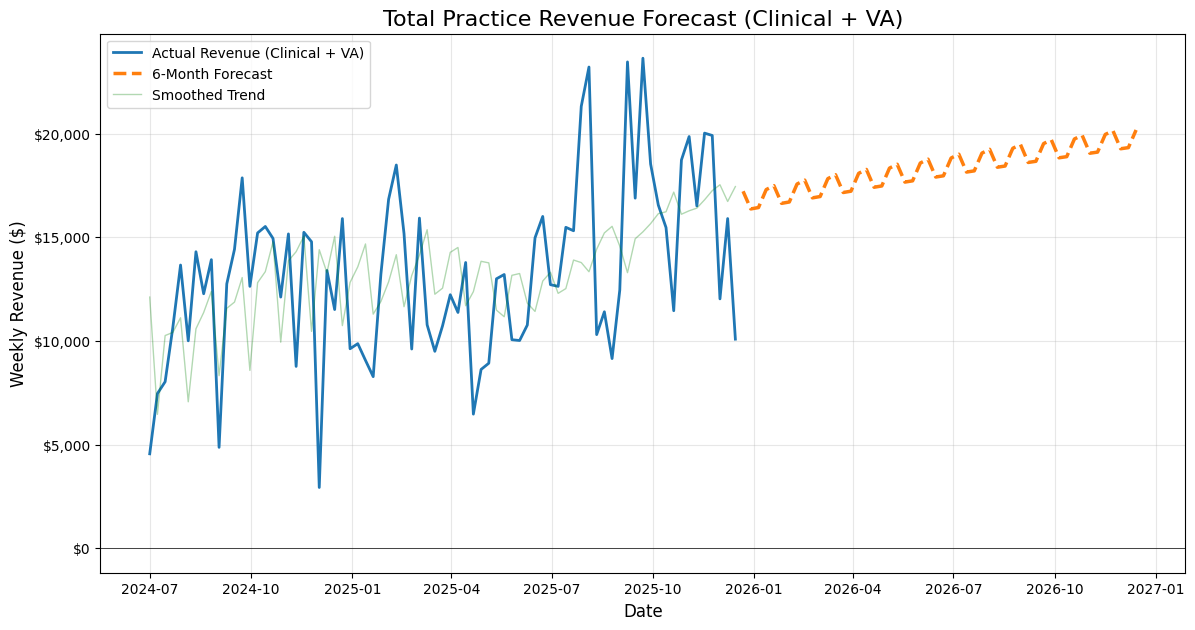


      TOTAL PRACTICE FORECAST SUMMARY
Avg Weekly Revenue (2025):    $13,279.76
Forecasted Weekly Revenue:    $18,333.46
Projected Growth Trend:       +38.1%
--------------------------------------------------
Top 3 Predicted Revenue Weeks:
  Week of 2026-12-14: $20,176.76
  Week of 2026-11-23: $20,139.35
  Week of 2026-11-16: $19,962.69


In [8]:
# ==========================================
# TOTAL PRACTICE FORECAST (CLINICAL + VA)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from datetime import timedelta

# --- CONFIGURATION ---
FORECAST_WEEKS = 52  # Predict next 6 months
SEASONAL_PERIOD = 4  # Monthly cycle pattern

# 1. LOAD DATA
# ------------
if 'charges' not in locals() or 'df' not in locals():
    print("Loading Data...")
    try:
        charges = pd.read_csv('Charges Export CSV.csv')
        df = pd.read_csv('201 Bills and Payments.csv')  # The VA Data
    except:
        print("Error: Files not found.")

# 2. PROCESS CLINICAL REVENUE (Standard Logic)
# --------------------------------------------
# Safety Name Fix
if 'claim ID' in charges.columns: charges.rename(columns={'claim ID': 'Claim ID'}, inplace=True)


# Clean Currency
def clean_curr(x):
    if isinstance(x, str):
        x = x.replace('$', '').replace(',', '').strip()
        if '(' in x and ')' in x: x = '-' + x.replace('(', '').replace(')', '')
    return pd.to_numeric(x, errors='coerce')


charges['Service Charge Amount'] = charges['Service Charge Amount'].apply(clean_curr).fillna(0)
adj_cols = ['Pri Ins Insurance Contract Adjustment', 'Sec Ins Insurance Contract Adjustment',
            'Other Ins Insurance Contract Adjustment']
charges['Total_Contract_Adj'] = 0
for col in adj_cols:
    if col in charges.columns:
        charges['Total_Contract_Adj'] += charges[col].apply(clean_curr).fillna(0)

# Calculate Truth (Allowed)
charges['Allowed Amount'] = charges['Service Charge Amount'] - charges['Total_Contract_Adj']
charges['Date Of Service'] = pd.to_datetime(charges['Date Of Service'])

# Create Clinical Stream
clinical_stream = charges[['Date Of Service', 'Allowed Amount']].rename(columns={'Allowed Amount': 'Revenue'}).copy()
clinical_stream['Source'] = 'Clinical'

# 3. PROCESS VA REVENUE (Fee Schedule Logic)
# ------------------------------------------
# Clean Dates
df = df.rename(columns={'Unnamed: 0': '201 ID', 'Sarah Suggs ': 'Provider'})
df['Date of Service'] = df['Date of Service'].ffill()
df['Date of Service'] = pd.to_datetime(df['Date of Service'], errors='coerce')
df = df.dropna(subset=['Date of Service']).fillna('0')

# Clean Columns
for col in ['Focused DBQs', 'Routine IMOs', 'Gen Med DBQs', 'No Show', 'TBI']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)

# Mappings
dbq_map = {'Visual': '0', 'r-tbi': '0', '1--5': '1-5', 'bp check': '0', 'nan': '0', '': '0'}
imo_map = {'7/9': '7-9', '1/3': '1-3', '0': '0', '1-5': '1-3', '1': '1-3', '4': '4-6', '7': '7-9', '6-10': '4-6'}
gen_med_map = {'0': '0', 'BP CHECK': '0', '11-13': '11-15', '1-6': '1-5', '7': '6-10', '6': '6-10', '??': '0'}

df['Focused DBQs'] = df['Focused DBQs'].replace(dbq_map)
df['Routine IMOs'] = df['Routine IMOs'].replace(imo_map)
df['Gen Med DBQs'] = df['Gen Med DBQs'].replace(gen_med_map)

# Fee Schedule
fees = {
    'GM_DBQs': {'0': 0, '1-5': 250, '6-10': 330, '11-15': 410, '16+': 550},
    'Focused': {'0': 0, '1-5': 200, '6-10': 280, '11-15': 370, '16+': 480},
    'TBI': 250,
    'IMO': {'0': 0, '1-3': 150, '4-6': 260, '7-9': 330, '10-12': 350, '13-15': 465, '16-18': 525, '19+': 600},
    'No_Show': {'0': 0, '1': 60}
}


def fee_calc(row):
    f_fee = fees['Focused'].get(row['Focused DBQs'], 0)
    imo_fee = fees['IMO'].get(row['Routine IMOs'], 0)
    gmed_fee = fees['GM_DBQs'].get(row['Gen Med DBQs'], 0)
    noshow_fee = fees['No_Show'].get(row['No Show'], 0)
    tbi_fee = 250 if row['TBI'] not in ['0', 'nan', '', 'no', 'false'] else 0
    return f_fee + imo_fee + gmed_fee + noshow_fee + tbi_fee


df['Fees'] = df.apply(fee_calc, axis=1)

# Create VA Stream
va_stream = df[['Date of Service', 'Fees']].rename(
    columns={'Date of Service': 'Date Of Service', 'Fees': 'Revenue'}).copy()
va_stream['Source'] = 'VA/DBQ'

# 4. MERGE & AGGREGATE
# --------------------
total_stream = pd.concat([clinical_stream, va_stream], ignore_index=True)

# Filter for 2025 Analysis Period
analysis_start = '2024-07-01'
analysis_end = '2025-12-12'

ts_data = total_stream[
    (total_stream['Date Of Service'] >= analysis_start) &
    (total_stream['Date Of Service'] <= analysis_end)
    ].copy()

# Group by Week (Monday Start)
weekly_rev = ts_data.groupby(pd.Grouper(key='Date Of Service', freq='W-MON'))['Revenue'].sum()
weekly_rev = weekly_rev.asfreq('W-MON', fill_value=0)  # Fill gaps

print(f"Total Revenue Analyzed (2025 YTD): ${weekly_rev.sum():,.2f}")

# 5. RUN FORECAST (HOLT-WINTERS)
# ------------------------------
try:
    model = ExponentialSmoothing(
        weekly_rev,
        trend='add',
        seasonal='add',
        seasonal_periods=SEASONAL_PERIOD,
        damped_trend=True
    ).fit()

    forecast = model.forecast(FORECAST_WEEKS)

    # Create forecast dates
    last_date = weekly_rev.index[-1]
    forecast_dates = [last_date + timedelta(weeks=x) for x in range(1, FORECAST_WEEKS + 1)]
    forecast_series = pd.Series(forecast.values, index=forecast_dates)

    # 6. VISUALIZATION
    # ----------------
    plt.figure(figsize=(14, 7))

    # Plot Historical
    plt.plot(weekly_rev.index, weekly_rev, label='Actual Revenue (Clinical + VA)', color='#1f77b4', linewidth=2)

    # Plot Forecast
    plt.plot(forecast_series.index, forecast_series, label='6-Month Forecast', color='#ff7f0e', linestyle='--',
             linewidth=2.5)

    # Plot Trend Line (Model Fit)
    plt.plot(weekly_rev.index, model.fittedvalues, color='green', alpha=0.3, label='Smoothed Trend', linewidth=1)

    plt.title(f'Total Practice Revenue Forecast (Clinical + VA)', fontsize=16)
    plt.ylabel('Weekly Revenue ($)', fontsize=12)
    plt.xlabel('Date', fontsize=12)
    plt.axhline(0, color='black', linewidth=0.5)

    # Format Y Axis
    current_values = plt.gca().get_yticks()
    plt.gca().set_yticklabels(['${:,.0f}'.format(x) for x in current_values])

    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

    # 7. SUMMARY METRICS
    # ------------------
    avg_hist = weekly_rev.mean()
    avg_forecast = forecast_series.mean()
    growth = ((avg_forecast - avg_hist) / avg_hist) * 100

    print("\n" + "=" * 50)
    print("      TOTAL PRACTICE FORECAST SUMMARY")
    print("=" * 50)
    print(f"Avg Weekly Revenue (2025):    ${avg_hist:,.2f}")
    print(f"Forecasted Weekly Revenue:    ${avg_forecast:,.2f}")
    print(f"Projected Growth Trend:       {growth:+.1f}%")
    print("-" * 50)
    print("Top 3 Predicted Revenue Weeks:")
    top_weeks = forecast_series.sort_values(ascending=False).head(3)
    for date, val in top_weeks.items():
        print(f"  Week of {date.date()}: ${val:,.2f}")

except Exception as e:
    print(f"Forecasting Error: {e}")
    print("Ensure you have at least 8 weeks of combined data.")

Error: Could not find charges file.
Total Primary Care Charges Analyzed: $1,177,711.06


C:\Users\jenks\AppData\Local\Temp\ipykernel_39828\3679862468.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['${:,.0f}'.format(x) for x in current_values])


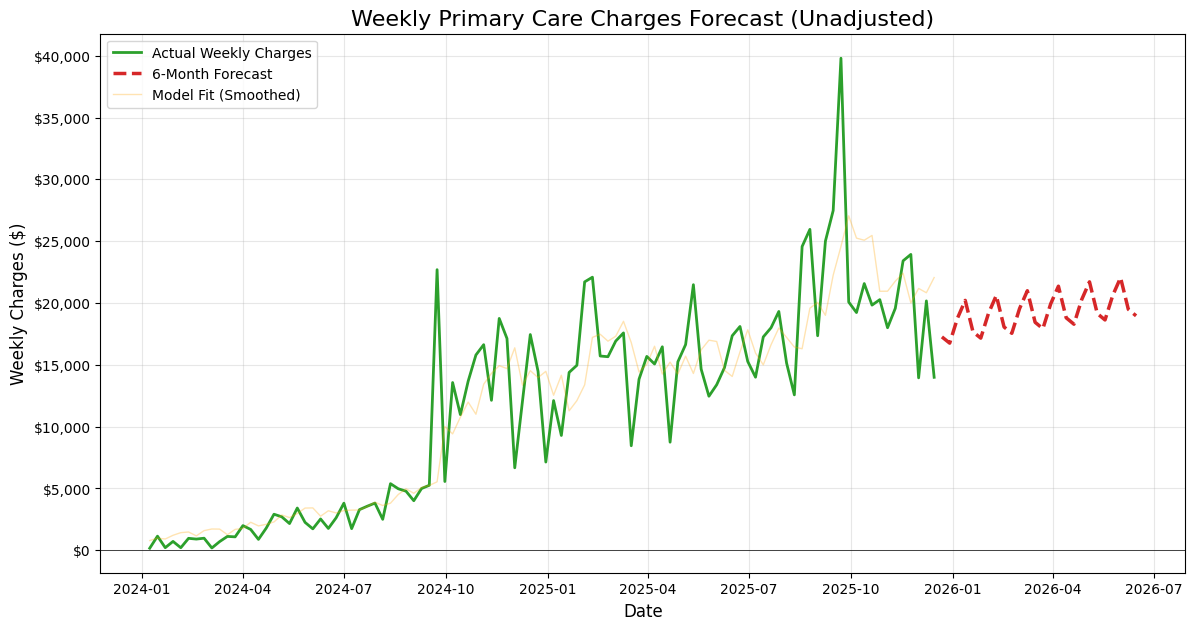


  WEEKLY PRIMARY CARE CHARGES FORECAST SUMMARY
Historical Avg Weekly Charges: $11,546.19
Projected Avg Weekly Charges:  $19,203.99
Projected Growth/Trend:        +66.3%
--------------------------------------------------
Top 3 Predicted Weeks:
  Week of 2026-06-01: $22,046.98
  Week of 2026-05-04: $21,708.00
  Week of 2026-04-06: $21,355.22


In [9]:
# ==========================================
# WEEKLY PRIMARY CARE CHARGES FORECAST
# (Unadjusted Service Charge Amount)
# ==========================================

# --- CONFIGURATION ---
FORECAST_WEEKS = 26  # Predict next 6 months
SEASONAL_PERIOD = 4  # Assume a 4-week (monthly) billing cycle pattern

# 1. LOAD DATA
# ------------
try:
    charges = pd.read_csv('260101 Charges Report.csv')
except:
    print("Error: Could not find charges file.")

# Safety Column Fixes
if 'claim ID' in charges.columns:
    charges.rename(columns={'claim ID': 'Claim ID'}, inplace=True)


# Clean Currency
def clean_curr(x):
    if isinstance(x, str):
        x = x.replace('$', '').replace(',', '').strip()
        if '(' in x and ')' in x:
            x = '-' + x.replace('(', '').replace(')', '')
    return pd.to_numeric(x, errors='coerce')


charges['Service Charge Amount'] = charges['Service Charge Amount'].apply(clean_curr).fillna(0)
charges['Date Of Service'] = pd.to_datetime(charges['Date Of Service'])

# 2. PREPARE TIME SERIES (WEEKLY AGGREGATION)
# -------------------------------------------
# Filter for analysis period
ts_data = charges[
    (charges['Date Of Service'] >= '2024-01-01') &
    (charges['Date Of Service'] <= '2025-12-12')
].copy()

# Group by Week (Monday Start) - Using SERVICE CHARGE AMOUNT (unadjusted)
weekly_charges = ts_data.groupby(pd.Grouper(key='Date Of Service', freq='W-MON'))['Service Charge Amount'].sum()

# Fill missing weeks with 0
weekly_charges = weekly_charges.asfreq('W-MON', fill_value=0)

print(f"Total Primary Care Charges Analyzed: ${weekly_charges.sum():,.2f}")

# 3. RUN THE HOLT-WINTERS MODEL
# -----------------------------
try:
    model = ExponentialSmoothing(
        weekly_charges,
        trend='add',
        seasonal='add',
        seasonal_periods=SEASONAL_PERIOD,
        damped_trend=True
    ).fit()

    # Generate Forecast
    forecast = model.forecast(FORECAST_WEEKS)

    # Create forecast dates
    last_date = weekly_charges.index[-1]
    forecast_dates = [last_date + timedelta(weeks=x) for x in range(1, FORECAST_WEEKS + 1)]
    forecast_series = pd.Series(forecast.values, index=forecast_dates)

    # 4. VISUALIZATION
    # ----------------
    plt.figure(figsize=(14, 7))

    # Plot Historical
    plt.plot(weekly_charges.index, weekly_charges, label='Actual Weekly Charges', color='#2ca02c', linewidth=2)

    # Plot Forecast
    plt.plot(forecast_series.index, forecast_series, label='6-Month Forecast', color='#d62728', linestyle='--',
             linewidth=2.5)

    # Plot Trend Line
    plt.plot(weekly_charges.index, model.fittedvalues, color='orange', alpha=0.3, label='Model Fit (Smoothed)',
             linewidth=1)

    plt.title('Weekly Primary Care Charges Forecast (Unadjusted)', fontsize=16)
    plt.ylabel('Weekly Charges ($)', fontsize=12)
    plt.xlabel('Date', fontsize=12)
    plt.axhline(0, color='black', linewidth=0.5)

    # Format Y Axis
    current_values = plt.gca().get_yticks()
    plt.gca().set_yticklabels(['${:,.0f}'.format(x) for x in current_values])

    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

    # 5. SUMMARY METRICS
    # ------------------
    avg_hist = weekly_charges.mean()
    avg_forecast = forecast_series.mean()
    growth = ((avg_forecast - avg_hist) / avg_hist) * 100

    print("\n" + "=" * 50)
    print("  WEEKLY PRIMARY CARE CHARGES FORECAST SUMMARY")
    print("=" * 50)
    print(f"Historical Avg Weekly Charges: ${avg_hist:,.2f}")
    print(f"Projected Avg Weekly Charges:  ${avg_forecast:,.2f}")
    print(f"Projected Growth/Trend:        {growth:+.1f}%")
    print("-" * 50)
    print("Top 3 Predicted Weeks:")
    top_weeks = forecast_series.sort_values(ascending=False).head(3)
    for date, val in top_weeks.items():
        print(f"  Week of {date.date()}: ${val:,.2f}")

except Exception as e:
    print(f"Forecasting Error: {e}")
    print("Ensure you have at least 8 weeks of data.")


  MONTHLY SERVICE CHARGES - LAST 12 MONTHS
         Month Total Charges
 February 2025    $25,852.00
    March 2025    $58,418.75
    April 2025    $60,675.93
      May 2025    $70,001.00
     June 2025    $68,896.80
     July 2025    $78,532.41
   August 2025    $85,597.73
September 2025   $115,944.19
  October 2025    $92,206.68
 November 2025    $78,420.34
 December 2025    $87,599.10
  January 2026    $86,053.05
 February 2026    $55,605.77
--------------------------------------------------
Grand Total: $963,803.75
Monthly Average: $74,138.75


C:\Users\jenks\AppData\Local\Temp\ipykernel_39828\4082725089.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['${:,.0f}'.format(x) for x in current_values])


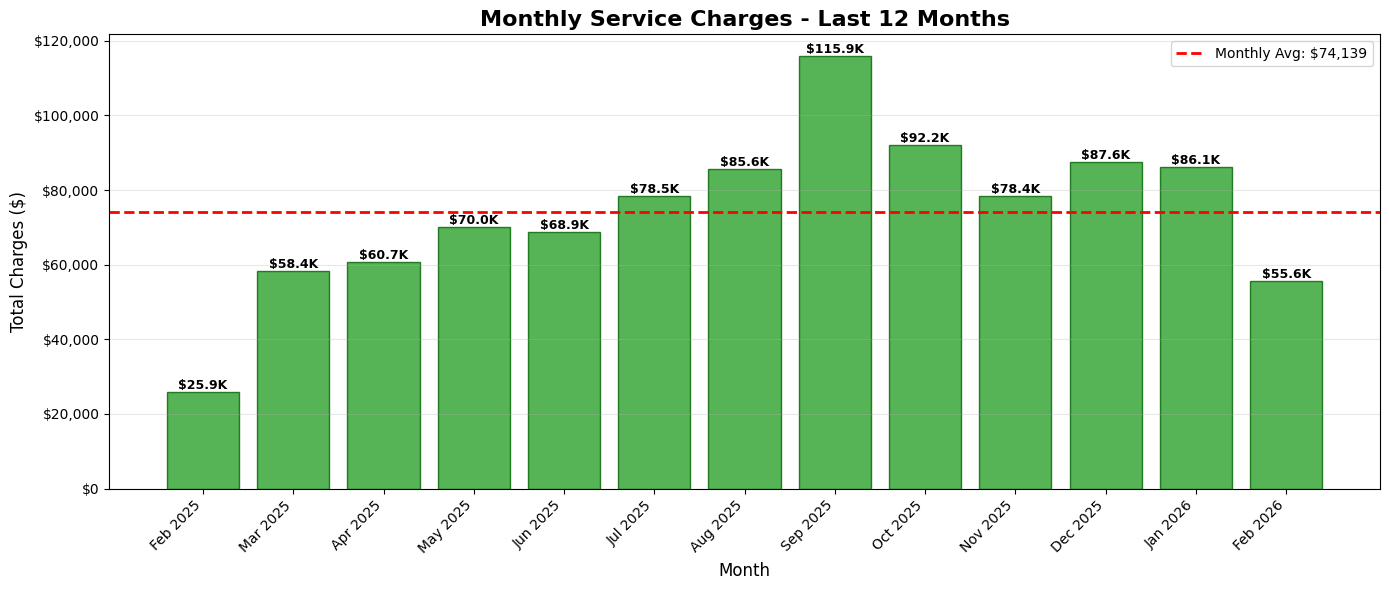

In [10]:
# ==========================================
# MONTHLY BREAKDOWN - LAST 12 MONTHS
# (Total Service Charge Amounts)
# ==========================================

# 1. LOAD DATA (if not already loaded)
# -------------------------------------
try:
    if 'charges' not in locals():
        charges = pd.read_csv('260101 Charges Report.csv')
except:
    print("Error: Could not find charges file.")


# Clean Currency
def clean_curr(x):
    if isinstance(x, str):
        x = x.replace('$', '').replace(',', '').strip()
        if '(' in x and ')' in x:
            x = '-' + x.replace('(', '').replace(')', '')
    return pd.to_numeric(x, errors='coerce')


# Safety Column Fixes
if 'claim ID' in charges.columns:
    charges.rename(columns={'claim ID': 'Claim ID'}, inplace=True)

charges['Service Charge Amount'] = charges['Service Charge Amount'].apply(clean_curr).fillna(0)
charges['Date Of Service'] = pd.to_datetime(charges['Date Of Service'])

# 2. FILTER LAST 12 MONTHS
# -------------------------
end_date = charges['Date Of Service'].max()
start_date = end_date - pd.DateOffset(months=12)

last_12_months = charges[
    (charges['Date Of Service'] >= start_date) &
    (charges['Date Of Service'] <= end_date)
].copy()

# 3. GROUP BY MONTH
# ------------------
monthly_charges = last_12_months.groupby(
    pd.Grouper(key='Date Of Service', freq='MS')
)['Service Charge Amount'].sum()

# 4. CREATE DISPLAY TABLE
# ------------------------
monthly_df = pd.DataFrame({
    'Month': monthly_charges.index.strftime('%B %Y'),
    'Total Charges': monthly_charges.values
})
monthly_df['Total Charges'] = monthly_df['Total Charges'].apply(lambda x: f"${x:,.2f}")

print("=" * 50)
print("  MONTHLY SERVICE CHARGES - LAST 12 MONTHS")
print("=" * 50)
print(monthly_df.to_string(index=False))
print("-" * 50)
print(f"Grand Total: ${monthly_charges.sum():,.2f}")
print(f"Monthly Average: ${monthly_charges.mean():,.2f}")
print("=" * 50)

# 5. VISUALIZATION
# -----------------
plt.figure(figsize=(14, 6))

bars = plt.bar(
    range(len(monthly_charges)),
    monthly_charges.values,
    color='#2ca02c',
    edgecolor='darkgreen',
    alpha=0.8
)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height,
             f'${height / 1000:.1f}K',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# X-axis labels
plt.xticks(range(len(monthly_charges)),
           monthly_charges.index.strftime('%b %Y'),
           rotation=45, ha='right')

# Formatting
plt.title('Monthly Service Charges - Last 12 Months', fontsize=16, fontweight='bold')
plt.ylabel('Total Charges ($)', fontsize=12)
plt.xlabel('Month', fontsize=12)

# Format Y axis
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['${:,.0f}'.format(x) for x in current_values])

# Add average line
avg = monthly_charges.mean()
plt.axhline(y=avg, color='red', linestyle='--', linewidth=2, label=f'Monthly Avg: ${avg:,.0f}')
plt.legend()

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [11]:
# ==========================================
# MONTHLY REVENUE ANALYSIS - LAST 12 MONTHS
# Charges, Adjustments, and Collections
# ==========================================
import pandas as pd

# 1. LOAD DATA
# -------------
charges = pd.read_csv('260106 Charges Report CSV.csv')

# Safety Column Fixes
if 'claim ID' in charges.columns:
    charges.rename(columns={'claim ID': 'Claim ID'}, inplace=True)


# Clean Currency Function
def clean_curr(x):
    if isinstance(x, str):
        x = x.replace('$', '').replace(',', '').strip()
        if '(' in x and ')' in x:
            x = '-' + x.replace('(', '').replace(')', '')
    return pd.to_numeric(x, errors='coerce')


# 2. CLEAN ALL FINANCIAL COLUMNS
# -------------------------------
charges['Service Charge Amount'] = charges['Service Charge Amount'].apply(clean_curr).fillna(0)
charges['Date Of Service'] = pd.to_datetime(charges['Date Of Service'])

# Adjustment columns (Contract adjustments)
adj_cols = ['Pri Ins Insurance Contract Adjustment', 'Sec Ins Insurance Contract Adjustment',
            'Other Ins Insurance Contract Adjustment']
charges['Total_Contract_Adj'] = 0
for col in adj_cols:
    if col in charges.columns:
        charges['Total_Contract_Adj'] += charges[col].apply(clean_curr).fillna(0)

# Payment columns - Insurance (CORRECTED column names)
ins_payment_cols = ['Pri Ins Insurance Payment', 'Sec Ins Insurance Payment', 'Other Ins Insurance Payment']
charges['Total_Ins_Payments'] = 0
for col in ins_payment_cols:
    if col in charges.columns:
        charges['Total_Ins_Payments'] += charges[col].apply(clean_curr).fillna(0)

# Patient payments
if 'Pat Payment Amount' in charges.columns:
    charges['Pat_Payments'] = charges['Pat Payment Amount'].apply(clean_curr).fillna(0)
else:
    charges['Pat_Payments'] = 0

# Total collected (Insurance + Patient)
charges['Total_Collected'] = charges['Total_Ins_Payments'] + charges['Pat_Payments']

# Adjusted Amount (Service Charge - Adjustment = Allowed/Expected)
charges['Adjusted_Amount'] = charges['Service Charge Amount'] - charges['Total_Contract_Adj']

# 3. FILTER LAST 12 MONTHS
# -------------------------
end_date = charges['Date Of Service'].max()
start_date = end_date - pd.DateOffset(months=12)

last_12_months = charges[
    (charges['Date Of Service'] >= start_date) &
    (charges['Date Of Service'] <= end_date)
].copy()

# 4. GROUP BY MONTH
# ------------------
monthly = last_12_months.groupby(
    pd.Grouper(key='Date Of Service', freq='MS')
).agg({
    'Service Charge Amount': 'sum',
    'Total_Contract_Adj': 'sum',
    'Adjusted_Amount': 'sum',
    'Total_Collected': 'sum'
}).reset_index()

# 5. CALCULATE PERCENTAGES
# -------------------------
monthly['Adjustment %'] = (monthly['Total_Contract_Adj'] / monthly['Service Charge Amount'] * 100).round(1)
monthly['Collected % of Charges'] = (monthly['Total_Collected'] / monthly['Service Charge Amount'] * 100).round(1)
monthly['Collected % of Adjusted'] = (monthly['Total_Collected'] / monthly['Adjusted_Amount'] * 100).round(1)

# 6. FORMAT FOR DISPLAY
# ----------------------
display_df = pd.DataFrame({
    'Month': monthly['Date Of Service'].dt.strftime('%b %Y'),
    'Svc Charges': monthly['Service Charge Amount'].apply(lambda x: f"${x:,.0f}"),
    'Adjustment': monthly['Total_Contract_Adj'].apply(lambda x: f"${x:,.0f}"),
    'Adj %': monthly['Adjustment %'].apply(lambda x: f"{x:.1f}%"),
    'Adj Charges': monthly['Adjusted_Amount'].apply(lambda x: f"${x:,.0f}"),
    'Collected': monthly['Total_Collected'].apply(lambda x: f"${x:,.0f}"),
    '% of Svc': monthly['Collected % of Charges'].apply(lambda x: f"{x:.1f}%"),
    '% of Adj': monthly['Collected % of Adjusted'].apply(lambda x: f"{x:.1f}%")
})

# 7. PRINT TABLE
# ---------------
print("=" * 110)
print("  MONTHLY REVENUE ANALYSIS - LAST 12 MONTHS")
print("=" * 110)
print(display_df.to_string(index=False))
print("-" * 110)

# Totals
total_charges = monthly['Service Charge Amount'].sum()
total_adj = monthly['Total_Contract_Adj'].sum()
total_adjusted = monthly['Adjusted_Amount'].sum()
total_collected = monthly['Total_Collected'].sum()

print(f"{'TOTALS:':<10} ${total_charges:>10,.0f}  ${total_adj:>10,.0f}  "
      f"{(total_adj/total_charges*100):>5.1f}%  ${total_adjusted:>10,.0f}  ${total_collected:>10,.0f}  "
      f"{(total_collected/total_charges*100):>5.1f}%  "
      f"{(total_collected/total_adjusted*100):>5.1f}%")
print("=" * 110)


FileNotFoundError: [Errno 2] No such file or directory: '260106 Charges Report CSV.csv'